In [1]:
import mlflow
import mlflow.sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)


In [4]:
mlflow.set_tracking_uri("file:///home/luc/ai-ml/MLOPS/MLFLOW&Dagshub/lecture/MLflow")  # pick a folder you own
mlflow.set_experiment("my_experiment")

# Start an MLflow run
with mlflow.start_run():
    n_estimators = 30
    max_depth = 6
    
    # Train model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)
    model.fit(X_train, y_train)
    
    # Predict and evaluate
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    # Log parameters, metrics, and model
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(model, "model")

    print(f"Logged model with accuracy: {acc}")

Traceback (most recent call last):
  File "/home/luc/miniconda3/envs/pytorchdl/lib/python3.10/site-packages/mlflow/store/tracking/file_store.py", line 329, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "/home/luc/miniconda3/envs/pytorchdl/lib/python3.10/site-packages/mlflow/store/tracking/file_store.py", line 427, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "/home/luc/miniconda3/envs/pytorchdl/lib/python3.10/site-packages/mlflow/store/tracking/file_store.py", line 1373, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "/home/luc/miniconda3/envs/pytorchdl/lib/python3.10/site-packages/mlflow/store/tracking/file_store.py", line 1366, in _read_helper
    result = read_yaml(root, file_name)
  File "/home/luc/miniconda3/envs/pytorchdl/lib/python3.10/site-packages/mlflow/utils/file_utils.py", line 310, in read_yaml
    raise MissingConfigException(f"Yaml file 

2025/12/24 03:40:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged model with accuracy: 1.0


### Logging Artifacts

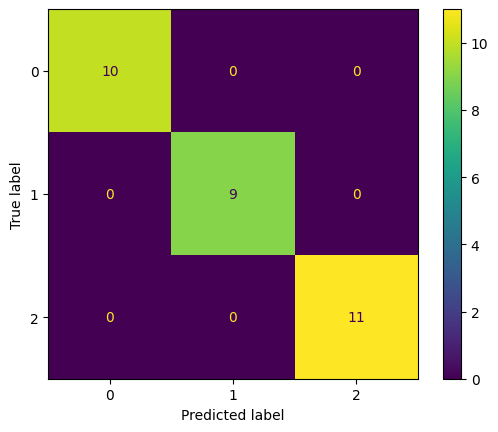

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.savefig("conf_matrix.png")
mlflow.log_artifact("conf_matrix.png")
